# ✈️ 01. Exploratory Data Analysis & Multi-Level Data Ingestion
### United Airlines Skyhack Operational Intelligence System

---

## 📌 Executive Summary & Business Problem
Frontline operations teams at commercial airlines (station controllers, ramp agents, gate supervisors, and dispatchers) coordinate hundreds of departures daily under strict block-time constraints. When a flight experiences operational friction—whether due to high passenger volume, baggage transfers, wheelchair assistance requests, or compressed ground turnaround—delays propagate across the hub network.

In this notebook, we perform **comprehensive exploratory data analysis (EDA)** across 4 distinct operational datasets:
1. **Flight-Level Operations**: Schedules, ground turnaround times, minimum equipment turn times, and delays.
2. **Passenger & Reservation Data (PNR)**: Passenger headcounts, lap infants, stroller users, and fare classes.
3. **Special Service Requests (SSR)**: Operational assist requests (airport wheelchairs, electric aisle chairs, unaccompanied minors).
4. **Baggage Logistics**: Origin, transfer, and tight-connection ("hot-transfer") baggage volumes.
5. **Global Airport Registry**: Origin and destination stations, international routing flags.

---


In [1]:
import sys
from pathlib import Path

# Add project root to path for robust imports across environments
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Set publication-quality plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(f"Environment initialized successfully. Project root: {root_dir}")


Environment initialized successfully. Project root: C:\Users\tusha\OneDrive\Desktop\Flight-Complexity-Analysis-and-Prediction


## 1. Ingestion of Multi-Source Operational Data
We load the raw datasets and intermediate processed summaries from the standardized `data/` directory.


In [2]:
raw_flights = pd.read_csv(root_dir / 'data/raw/Flight_Level_Data.csv')
pnr_remarks = pd.read_csv(root_dir / 'data/raw/PNR_Remark_Level_Data.csv')
airports = pd.read_csv(root_dir / 'data/raw/Airports_Data.csv')
overall_df = pd.read_csv(root_dir / 'data/processed/overall_complexity.csv')

print(f"Raw Flight Records: {raw_flights.shape}")
print(f"PNR Special Service Remarks: {pnr_remarks.shape}")
print(f"Airports Master: {airports.shape}")
print(f"Overall Complexity Table: {overall_df.shape}")


Raw Flight Records: (8099, 15)
PNR Special Service Remarks: (51698, 4)
Airports Master: (5612, 2)
Overall Complexity Table: (8099, 49)


## 2. Data Hygiene & Quality Audit
A critical requirement in enterprise data science is auditing data hygiene (missing rates, duplicate records, cardinality).


In [3]:
audit_summary = pd.DataFrame({
    'Total Rows': [len(raw_flights), len(pnr_remarks), len(airports), len(overall_df)],
    'Total Columns': [raw_flights.shape[1], pnr_remarks.shape[1], airports.shape[1], overall_df.shape[1]],
    'Missing Fields': [raw_flights.isna().any().sum(), pnr_remarks.isna().any().sum(), airports.isna().any().sum(), overall_df.isna().any().sum()],
    'Duplicates': [raw_flights.duplicated().sum(), pnr_remarks.duplicated().sum(), airports.duplicated().sum(), overall_df.duplicated().sum()]
}, index=['Flight Level', 'PNR Remarks', 'Airports', 'Overall Summary'])

audit_summary


,Total Rows,Total Columns,Missing Fields,Duplicates
Flight Level,8099,15,0,0
PNR Remarks,51698,4,0,0
Airports,5612,2,1,0
Overall Summary,8099,49,9,0


## 3. Turnaround Ground Time & Buffer Analysis
The core physics of flight turnarounds depend on the difference between scheduled ground time and the minimum required turn time:
$$\text{Buffer (mins)} = \text{Scheduled Ground Time} - \text{Minimum Turn Time}$$


C:\Users\tusha\AppData\Local\Temp\ipykernel_20996\1535459313.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_flights, x='carrier', y='turnaround_buffer', ax=axes[1], palette='Blues')


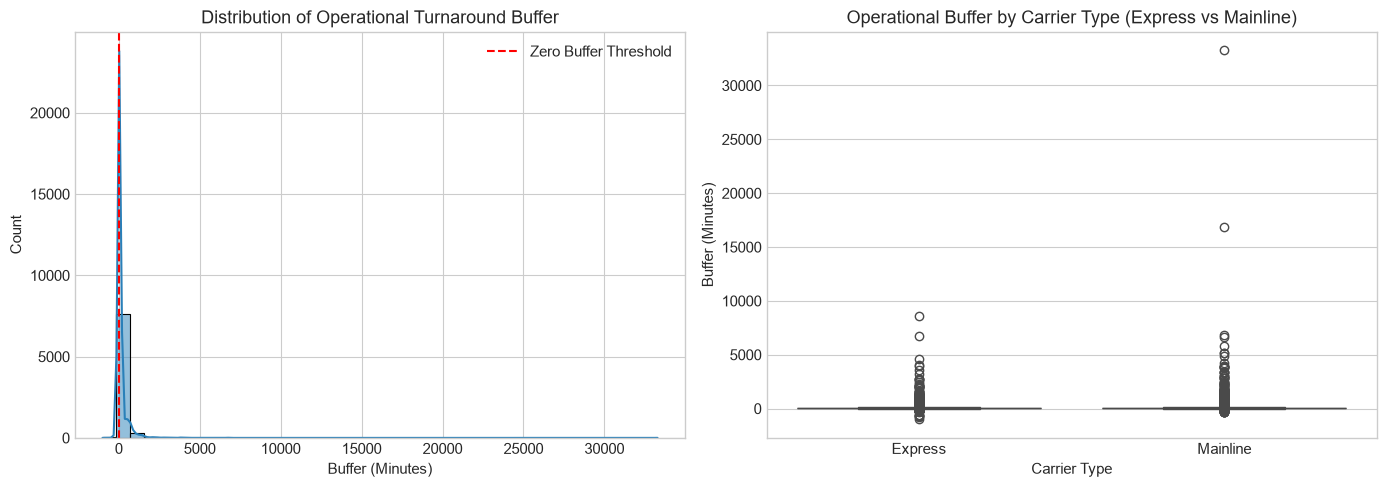

In [4]:
raw_flights['turnaround_buffer'] = raw_flights['scheduled_ground_time_minutes'] - raw_flights['minimum_turn_minutes']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(raw_flights['turnaround_buffer'], bins=40, kde=True, ax=axes[0], color='#2980B9')
axes[0].axvline(0, color='red', linestyle='--', label='Zero Buffer Threshold')
axes[0].set_title('Distribution of Operational Turnaround Buffer')
axes[0].set_xlabel('Buffer (Minutes)')
axes[0].legend()

sns.boxplot(data=raw_flights, x='carrier', y='turnaround_buffer', ax=axes[1], palette='Blues')
axes[1].set_title('Operational Buffer by Carrier Type (Express vs Mainline)')
axes[1].set_xlabel('Carrier Type')
axes[1].set_ylabel('Buffer (Minutes)')

plt.tight_layout()
plt.show()


## 4. Special Service Requests (SSR) Breakdown
Special service requests (wheelchairs, unaccompanied minors) heavily impact gate boarding times and staffing allocations.


C:\Users\tusha\AppData\Local\Temp\ipykernel_20996\452834032.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ssr_counts.values, y=ssr_counts.index, palette='Blues_r')


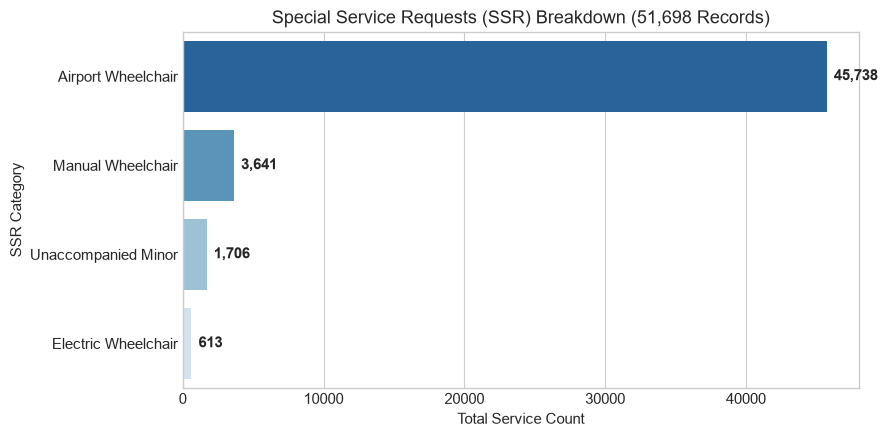

In [5]:
ssr_counts = pnr_remarks['special_service_request'].value_counts()

plt.figure(figsize=(9, 4.5))
sns.barplot(x=ssr_counts.values, y=ssr_counts.index, palette='Blues_r')
plt.title('Special Service Requests (SSR) Breakdown (51,698 Records)')
plt.xlabel('Total Service Count')
plt.ylabel('SSR Category')
for i, v in enumerate(ssr_counts.values):
    plt.text(v + 500, i, f"{v:,}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Baggage Handling & Hot Transfer Pressure
Connecting bags with tight connection windows (<45 minutes, "hot transfers") present the greatest risk of delayed departures and mishandled baggage claims.


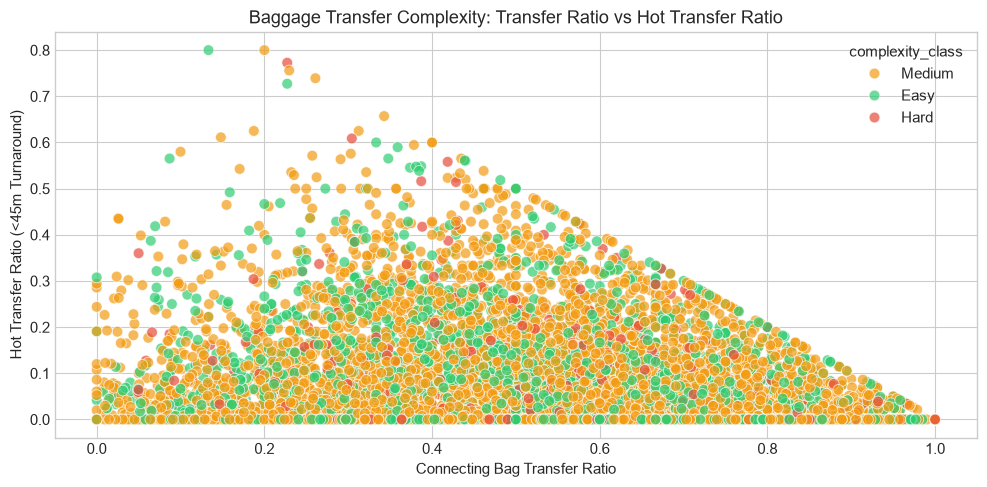

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(
    data=overall_df,
    x='transfer_ratio',
    y='hot_transfer_ratio',
    hue='complexity_class',
    palette={'Easy': '#2ECC71', 'Medium': '#F39C12', 'Hard': '#E74C3C'},
    alpha=0.7,
    s=60
)
ax.set_title('Baggage Transfer Complexity: Transfer Ratio vs Hot Transfer Ratio')
ax.set_xlabel('Connecting Bag Transfer Ratio')
ax.set_ylabel('Hot Transfer Ratio (<45m Turnaround)')
plt.tight_layout()
plt.show()


## 6. Key Takeaways & Strategic Next Steps
- **Data Completeness**: Clean 8,099 scheduled flights with comprehensive ground operational metrics.
- **SSR Factor**: Over 45,000 airport wheelchairs and 1,700 unaccompanied minors need to be integrated into the feature engineering pipeline.
- **Turnaround Vulnerability**: A noticeable portion of flights operate with less than 15 minutes of buffer time, creating high fragility to minor delays.
